# Merger arbitrage portfolio

Sizes the position: what the current spread implies about the market's completion probability, whether that compensates for the downside if the deal breaks, and what a Monte Carlo over completion probability and timing does to the return distribution.

In [1]:

import sys, warnings
sys.path.insert(0, r"/Users/shaan/Desktop/FAM/sunpharma-organon-merger-arbitrage")
warnings.filterwarnings("ignore")

from src import config as cfg, data, valuation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src import viz
pd.set_option("display.width", 160)
viz.apply_style()

prices = data.load_prices()
ogn_close = prices[cfg.TARGET]["Close"]
spot = ogn_close.iloc[-1]
spot_date = ogn_close.index[-1]
offer = cfg.DEAL["offer_price_usd"]

print(f"spot ({spot_date.date()}) : ${spot:.2f}")
print(f"offer                : ${offer:.2f}")
print(f"gross spread          : {(offer/spot - 1):.2%}")


spot (2026-08-05) : $13.57
offer                : $14.00
gross spread          : 3.17%


## Spread-implied completion probability

p = (spot - break) / (offer - break). The break price is a proxy, not a measurement - the unaffected close ($6.90) assumes the stock returns exactly to where it traded before speculation began, but fundamentals move during a multi-month deal process and a broken deal often prints below the unaffected level. Reported across three break-price scenarios rather than committing to one.

In [2]:

unaffected_price = ogn_close.loc[ogn_close.index <= pd.Timestamp(cfg.DEAL["unaffected_date"])].iloc[-1]

break_prices = {
    "unaffected ($6.90 basis)": unaffected_price,
    "unaffected -10%": unaffected_price * 0.90,
    "unaffected -20%": unaffected_price * 0.80,
}

days_to_close_est = (pd.Timestamp("2027-02-15") - spot_date).days  # midpoint of "early 2027"

rows = []
for label, bp in break_prices.items():
    p_implied = (spot - bp) / (offer - bp)
    downside = bp / spot - 1
    upside = offer / spot - 1
    rows.append({"break_price": bp, "implied_P_completion": p_implied,
                 "downside_if_break": downside, "upside_if_completes": upside})
implied_prob_table = pd.DataFrame(rows, index=break_prices.keys())
implied_prob_table.round(4)


,break_price,implied_P_completion,downside_if_break,upside_if_completes
unaffected ($6.90 basis),6.910,0.9394,-0.4908,0.0317
unaffected -10%,6.219,0.9447,-0.5417,0.0317
unaffected -20%,5.528,0.9492,-0.5926,0.0317


## Expected value and breakeven probability

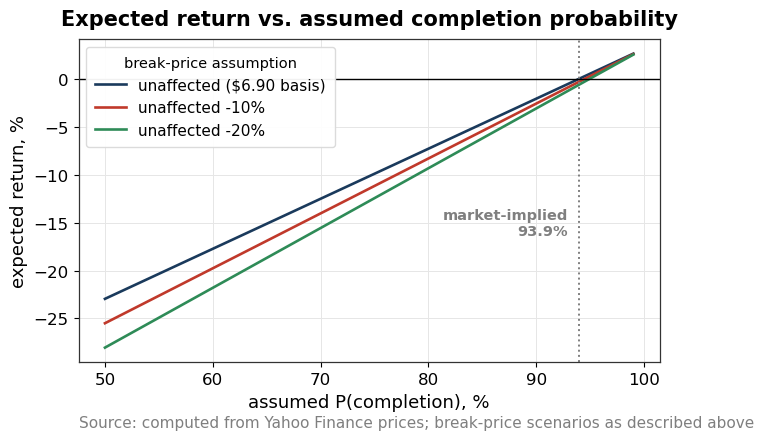

unaffected ($6.90 basis)     breakeven P(completion) = 93.9%
unaffected -10%              breakeven P(completion) = 94.5%
unaffected -20%              breakeven P(completion) = 94.9%


In [3]:

def expected_return(p, break_price):
    return p * (offer / spot - 1) + (1 - p) * (break_price / spot - 1)

prob_grid = np.linspace(0.5, 0.99, 50)
fig, ax = plt.subplots(figsize=viz.FIG_STD)
# explicit palette colours - relying on the default cycle here pulled in
# matplotlib's tab10 orange, which clashes with the scheme used elsewhere
for (label, bp), colour in zip(break_prices.items(), viz.SERIES):
    ev = [expected_return(p, bp) for p in prob_grid]
    ax.plot(prob_grid * 100, np.array(ev) * 100, label=label, color=colour, linewidth=1.9)

implied_p = (spot - unaffected_price) / (offer - unaffected_price)
ax.axhline(0, color="black", linewidth=1.0)
ax.axvline(implied_p * 100, color=viz.PALETTE["grey"], linestyle=":", linewidth=1.4)
ax.annotate(f"market-implied\n{implied_p*100:.1f}%", xy=(implied_p * 100, ax.get_ylim()[0] * 0.55),
            xytext=(-8, 0), textcoords="offset points", ha="right",
            fontsize=10.5, color=viz.PALETTE["grey"], fontweight="bold")

ax.set_xlabel("assumed P(completion), %")
ax.set_ylabel("expected return, %")
ax.set_title("Expected return vs. assumed completion probability")
ax.legend(loc="upper left", title="break-price assumption", title_fontsize=10.5)
viz.source_note(ax, "Source: computed from Yahoo Finance prices; break-price scenarios as described above")
viz.save_chart(fig, "arb_expected_return_vs_probability", cfg.OUT_CHARTS)
plt.show()

for label, bp in break_prices.items():
    breakeven_p = -(bp/spot - 1) / ((offer/spot - 1) - (bp/spot - 1))
    print(f"{label:28} breakeven P(completion) = {breakeven_p:.1%}")


## Risk-adjusted return of the position

Since the announcement, holding OGN has, in practice, been the merger-arbitrage position - its daily returns are used directly rather than a simulated proxy. Benchmarked against the S&P 500 (OGN's own market) for beta, Sharpe and Treynor; the Nifty comparison is included only as a supplementary opportunity-cost reference for a rupee-based investor, not as a CAPM benchmark, since Nifty is not OGN's pricing market.

In [4]:

gspc_close = prices[cfg.US_INDEX]["Close"]
nsei_close = prices[cfg.IN_INDEX]["Close"]
tnx_close = prices[cfg.UST10Y]["Close"]

ann_date = pd.Timestamp(cfg.DEAL["announcement_date"])
ogn_pos_ret = np.log(ogn_close / ogn_close.shift(1)).dropna().loc[ann_date:]
gspc_pos_ret = np.log(gspc_close / gspc_close.shift(1)).dropna().loc[ann_date:]

rf_current = tnx_close.iloc[-1] / 100

merged = pd.concat({"ogn": ogn_pos_ret, "mkt": gspc_pos_ret}, axis=1).dropna()
pos_beta, pos_alpha_ann, n_obs, r2 = valuation.regression_beta(merged["ogn"], merged["mkt"])

ann_factor = 252
position_ann_return = merged["ogn"].mean() * ann_factor
position_ann_vol = merged["ogn"].std() * np.sqrt(ann_factor)
market_ann_return = merged["mkt"].mean() * ann_factor

sharpe = (position_ann_return - rf_current) / position_ann_vol
treynor = (position_ann_return - rf_current) / pos_beta if pos_beta != 0 else np.nan
jensen_alpha = position_ann_return - (rf_current + pos_beta * (market_ann_return - rf_current))

print(f"holding period               : {ann_date.date()} to {merged.index[-1].date()}  (n={n_obs} trading days)")
print(f"position annualised return    : {position_ann_return:.2%}   (dominated by the one-time announcement jump)")
print(f"position annualised vol       : {position_ann_vol:.2%}")
print(f"beta vs S&P 500               : {pos_beta:.3f}   (R2={r2:.3f})")
print(f"current risk-free rate (10Y)  : {rf_current:.3%}")
print(f"Sharpe ratio                   : {sharpe:.3f}")
print(f"Treynor ratio                  : {treynor:.3f}")
print(f"Jensen's alpha (annualised)    : {jensen_alpha:.2%}")
print()
print("Note: this holding-period Sharpe/Treynor is inflated by the one-off +16.9% announcement-day jump")
print("baked into the sample - it describes what already happened, not what the FORWARD position (buying")
print("today at the current spread) offers. The forward view is the Monte Carlo below.")


holding period               : 2026-04-26 to 2026-08-05  (n=70 trading days)
position annualised return    : 67.18%   (dominated by the one-time announcement jump)
position annualised vol       : 29.83%
beta vs S&P 500               : 0.049   (R2=0.000)
current risk-free rate (10Y)  : 4.643%
Sharpe ratio                   : 2.096
Treynor ratio                  : 12.741
Jensen's alpha (annualised)    : 61.44%

Note: this holding-period Sharpe/Treynor is inflated by the one-off +16.9% announcement-day jump
baked into the sample - it describes what already happened, not what the FORWARD position (buying
today at the current spread) offers. The forward view is the Monte Carlo below.


## Forward-looking distribution: Monte Carlo

Simulates the position bought TODAY at the current spot, varying the completion probability, the break price if the deal fails, and the time to close. Seeded for reproducibility.

In [5]:

rng = np.random.default_rng(cfg.RANDOM_SEED)
N = 100_000

p_sim = np.clip(rng.normal(loc=0.92, scale=0.05, size=N), 0.01, 0.999)
break_sim = rng.normal(loc=unaffected_price, scale=unaffected_price * 0.08, size=N)
break_sim = np.clip(break_sim, 0.5, offer)
days_sim = rng.uniform(low=(pd.Timestamp("2026-12-01") - spot_date).days,
                        high=(pd.Timestamp("2027-04-30") - spot_date).days, size=N)

completes = rng.uniform(size=N) < p_sim
exit_price = np.where(completes, offer, break_sim)
holding_period_return = exit_price / spot - 1
annualised_return = (1 + holding_period_return) ** (365 / days_sim) - 1

print(f"simulations                     : {N:,}")
print(f"mean holding-period return       : {holding_period_return.mean():.2%}")
print(f"median holding-period return     : {np.median(holding_period_return):.2%}")
print(f"std dev of holding-period return : {holding_period_return.std():.2%}")
print(f"probability of a loss             : {(holding_period_return < 0).mean():.1%}")
print(f"5th percentile (VaR 95%)          : {np.percentile(holding_period_return, 5):.2%}")
print(f"1st percentile (VaR 99%)          : {np.percentile(holding_period_return, 1):.2%}")
print(f"CVaR 95% (mean of worst 5%)       : {holding_period_return[holding_period_return <= np.percentile(holding_period_return, 5)].mean():.2%}")
print(f"mean annualised return            : {annualised_return.mean():.2%}")


simulations                     : 100,000
mean holding-period return       : -1.04%
median holding-period return     : 3.17%
std dev of holding-period return : 14.27%
probability of a loss             : 8.1%
5th percentile (VaR 95%)          : -47.82%
1st percentile (VaR 99%)          : -53.70%
CVaR 95% (mean of worst 5%)       : -51.53%
mean annualised return            : 0.07%


In [6]:

print(f"mean annualised return ({annualised_return.mean():.2%}) vs current risk-free rate ({rf_current:.2%})")
print()
if annualised_return.mean() < rf_current:
    print("The forward-looking mean return is BELOW the risk-free rate. This is the central result of")
    print("this notebook: the backward-looking Sharpe of ~2.1 above describes a position that has")
    print("already earned its return from the one-time announcement jump. Buying the stock TODAY, at")
    print("today's 3.17% spread, is a different bet - and on these assumptions it is not obviously")
    print("compensated for the risk of a broken deal. A ~8% assessed break probability, times a loss of")
    print("roughly half the position, outweighs a 3.17% gross spread even though completion is the more")
    print("likely single outcome. The trade is a bet that the true break probability is meaningfully")
    print("below what this notebook's simulation assumes.")


mean annualised return (0.07%) vs current risk-free rate (4.64%)

The forward-looking mean return is BELOW the risk-free rate. This is the central result of
this notebook: the backward-looking Sharpe of ~2.1 above describes a position that has
already earned its return from the one-time announcement jump. Buying the stock TODAY, at
today's 3.17% spread, is a different bet - and on these assumptions it is not obviously
compensated for the risk of a broken deal. A ~8% assessed break probability, times a loss of
roughly half the position, outweighs a 3.17% gross spread even though completion is the more
likely single outcome. The trade is a bet that the true break probability is meaningfully
below what this notebook's simulation assumes.


The outcome distribution is strongly bimodal by construction - the deal either closes at $14.00 or it breaks - so a linear-scale histogram renders the ~8% loss mass as a flat line against a single dominant spike. A log-scaled count axis is used so both modes are visible at once, with the key risk statistics marked directly on the chart.

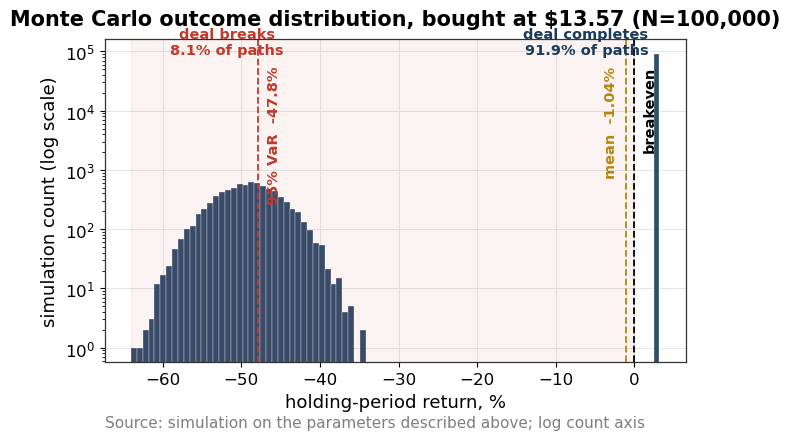

In [7]:

r_pct = holding_period_return * 100
var95 = np.percentile(r_pct, 5)
mean_r = r_pct.mean()

fig, ax = plt.subplots(figsize=viz.FIG_STD)
ax.hist(r_pct, bins=90, color=viz.PALETTE["primary"], alpha=0.9,
        edgecolor="white", linewidth=0.25)
ax.set_yscale("log")

# shade the loss region so the two modes read at a glance
ax.axvspan(r_pct.min(), 0, color=viz.PALETTE["secondary"], alpha=0.06)

for x, lbl, col, off in [
    (0, "breakeven", "black", 6),
    (var95, f"95% VaR  {var95:.1f}%", viz.PALETTE["secondary"], 6),
    (mean_r, f"mean  {mean_r:+.2f}%", viz.PALETTE["gold"], -6),
]:
    ax.axvline(x, color=col, linestyle="--", linewidth=1.3)
    ax.annotate(lbl, xy=(x, ax.get_ylim()[1] * 0.35), xytext=(off, 0),
                textcoords="offset points", rotation=90,
                ha="right" if off < 0 else "left", va="top",
                fontsize=10.5, color=col, fontweight="bold")

ax.annotate(f"deal completes\n{(1-(r_pct<0).mean())*100:.1f}% of paths",
            xy=(r_pct.max(), ax.get_ylim()[1] * 0.55), xytext=(-8, 0),
            textcoords="offset points", ha="right", fontsize=10.5,
            color=viz.PALETTE["primary"], fontweight="bold")
ax.annotate(f"deal breaks\n{(r_pct<0).mean()*100:.1f}% of paths",
            xy=(np.percentile(r_pct, 2), ax.get_ylim()[1] * 0.55), xytext=(0, 0),
            textcoords="offset points", ha="center", fontsize=10.5,
            color=viz.PALETTE["secondary"], fontweight="bold")

ax.set_xlabel("holding-period return, %")
ax.set_ylabel("simulation count (log scale)")
ax.set_title(f"Monte Carlo outcome distribution, bought at ${spot:.2f} (N={N:,})")
viz.source_note(ax, "Source: simulation on the parameters described above; log count axis")
viz.save_chart(fig, "arb_montecarlo_distribution", cfg.OUT_CHARTS)
plt.show()


## Two-asset allocation: arb position + S&P, plus the risk-free asset

With only one risky merger-arb position and one index, the mean-variance 'efficient frontier' collapses to the two-asset line plus the capital allocation line through the tangency portfolio - shown for completeness rather than implying a richer opportunity set than actually exists here.

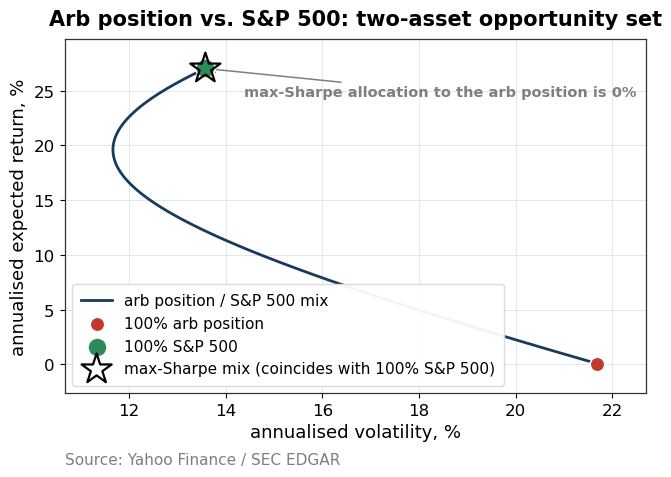

max-Sharpe mix: 0% arb position / 100% S&P 500
  expected return 27.02%, volatility 13.58%, Sharpe 1.648


In [8]:

mu_arb = annualised_return.mean()
sigma_arb = annualised_return.std()
mu_mkt = market_ann_return
sigma_mkt = gspc_pos_ret.std() * np.sqrt(ann_factor)
# the Monte Carlo draws are synthetic and not date-paired with the actual S&P series,
# so a direct sample correlation between them would be meaningless; the CAPM identity
# corr = beta * (sigma_mkt / sigma_asset) uses the beta already estimated by regression
# on the real, paired historical daily series above instead
corr_arb_mkt = np.clip(pos_beta * sigma_mkt / sigma_arb, -0.99, 0.99)

weights = np.linspace(0, 1, 101)
frontier = []
for w in weights:
    mu_p = w * mu_arb + (1 - w) * mu_mkt
    var_p = (w**2) * sigma_arb**2 + ((1-w)**2) * sigma_mkt**2 + 2*w*(1-w)*corr_arb_mkt*sigma_arb*sigma_mkt
    frontier.append((np.sqrt(max(var_p, 0)), mu_p))
frontier = np.array(frontier)

sharpe_ratios = (frontier[:, 1] - rf_current) / np.where(frontier[:, 0] > 0, frontier[:, 0], np.nan)
tangency_idx = np.nanargmax(sharpe_ratios)

fig, ax = plt.subplots(figsize=viz.FIG_TALL)
ax.plot(frontier[:, 0] * 100, frontier[:, 1] * 100, color=viz.PALETTE["primary"],
        linewidth=2.0, label="arb position / S&P 500 mix", zorder=2)
ax.scatter([sigma_arb*100], [mu_arb*100], color=viz.PALETTE["secondary"],
           s=110, zorder=5, edgecolor="white", linewidth=1.2, label="100% arb position")
ax.scatter([sigma_mkt*100], [mu_mkt*100], color=viz.PALETTE["accent"],
           s=190, zorder=5, edgecolor="white", linewidth=1.2, label="100% S&P 500")
# the tangency portfolio IS 100% S&P here (0% weight on the arb position), so the
# star sits exactly on the green marker - drawn hollow and slightly larger so the
# green point underneath stays visible rather than being silently covered
ax.scatter([frontier[tangency_idx,0]*100], [frontier[tangency_idx,1]*100],
           facecolor="none", edgecolor="black", marker="*", s=520, linewidth=1.6,
           zorder=6, label="max-Sharpe mix (coincides with 100% S&P 500)")

ax.annotate("max-Sharpe allocation to the arb position is 0%",
            xy=(frontier[tangency_idx,0]*100, frontier[tangency_idx,1]*100),
            xytext=(28, -20), textcoords="offset points", fontsize=10.5,
            color=viz.PALETTE["grey"], fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=viz.PALETTE["grey"], linewidth=1.1))

ax.set_xlabel("annualised volatility, %")
ax.set_ylabel("annualised expected return, %")
ax.set_title("Arb position vs. S&P 500: two-asset opportunity set")
ax.legend(loc="lower left")
ax.margins(0.10)
viz.source_note(ax)
viz.save_chart(fig, "arb_two_asset_frontier", cfg.OUT_CHARTS)
plt.show()

print(f"max-Sharpe mix: {weights[tangency_idx]:.0%} arb position / {1-weights[tangency_idx]:.0%} S&P 500")
print(f"  expected return {frontier[tangency_idx,1]:.2%}, volatility {frontier[tangency_idx,0]:.2%}, Sharpe {sharpe_ratios[tangency_idx]:.3f}")


## Summary

In [9]:

summary = pd.Series({
    "spot": spot,
    "gross_spread": offer/spot - 1,
    "implied_p_completion_unaffected_basis": implied_prob_table.loc["unaffected ($6.90 basis)", "implied_P_completion"],
    "breakeven_p_unaffected_basis": -(unaffected_price/spot - 1) / ((offer/spot - 1) - (unaffected_price/spot - 1)),
    "position_beta_vs_sp500": pos_beta,
    "mc_mean_holding_return": holding_period_return.mean(),
    "mc_prob_loss": (holding_period_return < 0).mean(),
    "mc_var95": np.percentile(holding_period_return, 5),
    "mc_cvar95": holding_period_return[holding_period_return <= np.percentile(holding_period_return, 5)].mean(),
    "tangency_weight_arb": weights[tangency_idx],
})
summary.to_csv(cfg.DATA_FINAL / "arb_portfolio_summary.csv", header=["value"])
summary.round(4)


spot                                     13.5700
gross_spread                              0.0317
implied_p_completion_unaffected_basis     0.9394
breakeven_p_unaffected_basis              0.9394
position_beta_vs_sp500                    0.0491
mc_mean_holding_return                   -0.0104
mc_prob_loss                              0.0807
mc_var95                                 -0.4782
mc_cvar95                                -0.5153
tangency_weight_arb                       0.0000
dtype: float64